<!-- Title Slide -->

<table>
<tr>
<td style="width:40%; vertical-align:middle; text-align:center;">
  <img src="https://maartengr.github.io/BERTopic/logo.png" alt="Topic Modeling Illustration" width="300"/>
</td>
<td style="width:60%; vertical-align:middle; padding-left:20px;">

  # 📝 Topic Modeling with BERTopic
  ## Session: Text Embeddings and Dimensionality Reduction

  <br>
  <br>
  <span style="font-size:1.2em; color:gray;">
    Michael Jantscher · Know Center Research GmbH
  </span>

</td>
</tr>
</table>


# 👋 Michael Jantscher

<img src="./images/profil_michael.jpg" alt="Michael Jantscher" width="250"/>

**Senior Researcher** - Know Center Research GmbH

---

### 🟢 Focus Areas
- Natural Language Processing (NLP) in medical & clinical domains
- Causal reasoning in healthcare and (neuro)radiology
- Multimodal and Hybrid Agentic AI systems


# 📌 What is a Text Embedding Vector ?- Formal Definition
* Numerical representation of text (words, sentences or documents) in a multi-dimensional space
* Captures meaning and context
* Semantic similar words/sentences/documents -> vectors closer together

In [ ]:
from IPython.display import HTML
HTML("""
<style>
.reveal .slides section { text-align: left !important; }
.reveal h1, .reveal h2, .reveal h3, .reveal p, .reveal table { text-align: left !important; }
.reveal table th, .reveal table td { text-align: left !important; }
</style>
""")

In [16]:
import pandas as pd
from sentence_transformers import SentenceTransformer
st_model_small = SentenceTransformer('all-minilm-l6-v2')

sample_string = "I really like this summer school!"

sample_string_embedding = st_model_small.encode(sample_string)
df = pd.DataFrame({
    "text": [sample_string],
    "embedding": [sample_string_embedding]
})
df

Loading weights: 100%|██████████| 103/103 [00:00<00:00, 3575.38it/s]


,text,embedding
0,I really like this summer school!,"[-0.05714613, -0.05354339, 0.04545712, 0.01507..."


## Why Use Embedding Vectors Instead of Strings?

### 🟢 Drawbacks with Raw Strings
- Computers see `"dog"` as just `"d", "o", "g"` — no understanding of meaning
- Hard to measure **similarity** or **relationships** between words
- Not suitable for **search, clustering, or ML models**

---

### 🟠️ Benefits of Embeddings
- **Numerical Representation:** Converts text into vectors that algorithms understand
- **Capture Meaning:** Similar words or sentences are close in vector space
- **Efficient & Scalable:** Enables fast similarity search with dot product or cosine similarity
- **Handle Synonyms & Context:** `"car"` ≈ `"automobile"`, context-aware models disambiguate `"bank"`

---

### 🔵 Example

| Text      | Raw Representation         | Embedding (Example)          |
|-----------|---------------------------|-----------------------------|
| `"dog"`   | `"d", "o", "g"`           | `[0.12, -0.45, 0.87, ...]`  |
| `"puppy"` | `"p", "u", "p", "p", "y"` | `[0.11, -0.48, 0.90, ...]`  |

*Vectors are close → words are semantically similar*


# 💡 Uses Cases of Text Embedding Vectors

| **Use Case**                   | **Example** |
|--------------------------------|-------------|
| **Semantic Search**         | Search “doctor” → find content on “physicians” or “healthcare providers” even without exact keywords |
| **Recommendation Systems**  | Suggest similar research papers, movies, or products based on descriptions or reviews |
| **Sentiment Analysis**      | Understand tone (positive/negative/neutral) beyond simple keywords in tweets or reviews |
| **Clustering & Topic Modeling** | Group thousands of news articles or support tickets by topic automatically |
| **Chatbots & Virtual Assistants** | Improve NLU so bots answer contextually, not just by keyword |
| **Fraud Detection**        | Spot unusual or suspicious text patterns in financial or insurance claims |

---



# 🦖 Pre-Embedding Area
📌 **Definition:**
Early NLP approaches represented text as **sparse, high-dimensional vectors**.
Each dimension corresponded to a **unique word or token**, with no sense of meaning or context.

---

### Bag-of-Words (BoW)
- Represents documents as a **vector of word counts**
- Ignores grammar, order, and semantics
- Example:
  `"I like NLP"` → `[1, 1, 1, 0, 0, ...]`

---

### TF-IDF (Term Frequency – Inverse Document Frequency)
- Adjusts raw counts to emphasize **rare, informative words** and downweight common words
- Example: “the” → low weight, “quantum” → high weight

---

#### TF-IDF Formula

$$TF\text{-}IDF(t, d) = TF(t, d) \times \log\left(\frac{N}{DF(t)}\right)$$

Where:
- (TF(t, d)\): Frequency of term \(t\) in document \(d\)
- \(DF(t)\): Number of documents containing \(t\)
- \(N\): Total number of documents


In [17]:
# Load parlamint dataset
df_parlamint = pd.read_csv("../../../datasets/parlamint/parlamint-it-is-2022.txt", sep="\t").head(2000)
df_parlamint_subset = df_parlamint.head(1000).copy(deep=True)
df_parlamint

# Group sentence by utterance (=Parent_ID)
df_parlamint_grouped = (df_parlamint.groupby(["Parent_ID"])["Text"]
                        .apply(lambda s: " ".join(s))
                        .reset_index(name="utterance_text")).head(100)

In [4]:
df_parlamint.head(5)

,ID,Parent_ID,Text
0,ParlaMint-IS_2022-01-17-20.seg2.1,ParlaMint-IS_2022-01-17-20.u1,President of the United States reports:
1,ParlaMint-IS_2022-01-17-20.seg3.1,ParlaMint-IS_2022-01-17-20.u1,"I have decided, according to the proposal of t..."
2,ParlaMint-IS_2022-01-17-20.seg4.1,ParlaMint-IS_2022-01-17-20.u1,"Arrange sites, January 11th, 2022."
3,ParlaMint-IS_2022-01-17-20.seg6.1,ParlaMint-IS_2022-01-17-20.u1,Katrín Jakobsdóttir's daughter.
4,ParlaMint-IS_2022-01-17-20.seg7.1,ParlaMint-IS_2022-01-17-20.u1,Presidential Letters for a meeting of the Gene...


In [5]:
df_parlamint_grouped.head(5)

,Parent_ID,utterance_text
0,ParlaMint-IS_2022-01-17-20.u1,President of the United States reports: I have...
1,ParlaMint-IS_2022-01-17-20.u10,"Before the weekend, an article by Stefánssonar..."
2,ParlaMint-IS_2022-01-17-20.u11,"I read this decision in Perconte, which is not..."
3,ParlaMint-IS_2022-01-17-20.u12,"In fact, this is shown in the letter quoted by..."
4,ParlaMint-IS_2022-01-17-20.u13,"Yes, that's right. That's right. A senator who..."


In [6]:
# Take a single utterance from the dataset
sample_utterance = df_parlamint[df_parlamint["Parent_ID"] == "ParlaMint-IS_2022-01-17-20.u1"]["Text"]
print("\n".join([e for e in sample_utterance]))

President of the United States reports:
I have decided, according to the proposal of the prime minister, that the Council should meet for an extended meeting on Monday, January 17, 2022 p.m. 3:00.
Arrange sites, January 11th, 2022.
Katrín Jakobsdóttir's daughter.
Presidential Letters for a meeting of the General Assembly for a subsequent meeting on January 17, 2022
I'd like to use this opportunity here after reading this letter and offer the highest. President and w. Senators welcome to New Year's Parliamentary Conferences.


In [7]:
from models import CountVectorizerEmbedder

# Adding just the utterance sample as vocabulary
cv_model = CountVectorizerEmbedder(vocabulary=sample_utterance, max_features=5, stop_words='english')
# cv_model = CountVectorizerEmbedder(vocabulary=sample_utterance)

cv_embeddings = cv_model.embed(sample_utterance)
print(f"Number features: {len(cv_model.embedding_model.get_feature_names_out())}", cv_model.embedding_model.get_feature_names_out())
print(f"Shape embedding array: {cv_embeddings.toarray().shape}")
df_cv_output = pd.DataFrame(columns=cv_model.embedding_model.get_feature_names_out(), data=cv_embeddings.toarray())
df_cv_output

Call 'transform' only...
Number features: 5 ['17' '2022' 'january' 'meeting' 'president']
Shape embedding array: (6, 5)


,17,2022,january,meeting,president
0,0,0,0,0,1
1,1,1,1,1,0
2,0,1,1,0,0
3,0,0,0,0,0
4,1,1,1,2,0
5,0,0,0,0,1


In [8]:
from models import TfIdfEmbedder

# Adding just the utterance sample as vocabulary
tfidf_model = TfIdfEmbedder(vocabulary=sample_utterance, max_features=5, stop_words='english')
tfidf_embeddings = tfidf_model.embed(sample_utterance)
print(f"Number features: {len(tfidf_model.embedding_model.get_feature_names_out())}", tfidf_model.embedding_model.get_feature_names_out())
print(f"Shape embedding array: {tfidf_embeddings.toarray().shape}")
df_tfidf_output = pd.DataFrame(columns=tfidf_model.embedding_model.get_feature_names_out(), data=tfidf_embeddings.toarray())
df_tfidf_output

Call 'transform' only...
Number features: 5 ['17' '2022' 'january' 'meeting' 'president']
Shape embedding array: (6, 5)


,17,2022,january,meeting,president
0,0.000000,0.000000,0.000000,0.000000,1.0
1,0.540298,0.456156,0.456156,0.540298,0.0
2,0.000000,0.707107,0.707107,0.000000,0.0
3,0.000000,0.000000,0.000000,0.000000,0.0
4,0.394497,0.333062,0.333062,0.788994,0.0
5,0.000000,0.000000,0.000000,0.000000,1.0


## Dense Text Embeddings

📌 **Definition:**
Dense embeddings represent words, sentences, or documents as **low-dimensional, dense vectors**
where similar meanings are **close together in vector space**.

---

### 🟢 Characteristics
- **Low-dimensional** (e.g., 100–1,536 dimensions, not vocab-sized)
- **Dense representation**: most values ≠ 0
- Captures **semantic meaning** and context
- Learned from data via **neural networks**

---

### 🟠️ Brief History
- **Word2Vec (2013)** – First widely used dense word embeddings (Mikolov et al.)
- **GloVe (2014)** – Global Vectors for word representation
- **FastText (2016)** – Adds subword information for better handling of rare words
- **ELMo (2018)** – Contextual word embeddings
- **BERT (2018)** – Contextual embeddings for entire sentences
- **OpenAI / Modern Embeddings (2020s)** – High-quality sentence/document embeddings (e.g., `text-embedding-3-large`)

---

### 🔴 Why It’s Better
- Reduces dimensionality dramatically
- Learns **semantic relationships**
- Powers modern **search, recommendation, and AI assistants**


## Word2Vec: CBOW & Skip-Gram Overview

### 🟢 What is Word2Vec?
- A **shallow, two-layer neural network** that learns word embeddings from context.
- Maps words to **dense vectors** in a continuous space; similar words are **close together**.
- Introduced by Mikolov et al., **2013**.

---

### 🟠️ Architectures

#### 🔹 Continuous Bag-of-Words (CBOW)
- Predicts the **center word** given its context words.
- Fast to train; works well for **frequent words**.

#### 🔹 Skip-Gram
- Predicts **context words** given a center word.
- Performs better for **rare words**, large datasets.

---

### 🔵 Why It Matters
- Captures **semantic relationships**:
  `king - man + woman ≈ queen`
- Major leap from sparse (BoW/TF-IDF) to **dense, meaningful embeddings**.


## Word2Vec: Training & Visual Intuition

### 🟢 Training Workflow
1. **One-hot encoding** for words.
2. **Hidden layer** = embedding lookup table.
3. **Output layer** predicts context words (softmax with negative sampling).
4. Final **hidden layer weights** = embeddings.

---

### 🟠 Visual Intuition

<table>
<tr>
<td width="50%">
<img src="./images/word2vec_diagrams.png" alt="Word2Vec Architecture" style="width:100%;">
</td>
<td width="50%">
  <img src="./images/skip_gram_net_arch.png" alt="Word2Vec Context" style="width:100%;">
</td>
</tr>
</table>

- Left: Skip-Gram architecture predicting context words.
- Right: Example of context window for a target word.
- Only the **embedding layer weights** are retained.

---

### Reference
- Israel G. (2017). *Word2Vec Explained*.
  [https://israelg99.github.io/2017-03-23-Word2Vec-Explained/](https://israelg99.github.io/2017-03-23-Word2Vec-Explained/)


## BERT: Contextual Embeddings

### 🟢 What is BERT?
- **Bidirectional Encoder Representations from Transformers** (2018, Google AI).
- Uses **Transformer architecture** to create **contextual word embeddings**:
  - Each word’s vector depends on **all surrounding words** (left & right context).
- Trained on **masked language modeling** and **next sentence prediction** tasks.

---

### 🟠 Key Innovations
- **Bidirectional**: Unlike Word2Vec/Glove, captures context from both sides.
- **Transformer encoder layers** with self-attention results in rich, deep embeddings.
- **Contextualization**: Same word gets **different vectors** depending on context
  (“bank” in “river bank” vs. “bank account”).

---

### 🔵 Visual Intuition

<img src="images/bert_embeddings.png" alt="BERT Transformer" style="width:40%;">

---

### Reference
- Devlin et al. (2018). *BERT: Pre-training of Deep Bidirectional Transformers for Language Understanding.*
  [https://arxiv.org/abs/1810.04805](https://arxiv.org/abs/1810.04805)


## Sentence Transformers Recap & Training

### 🟢 Key Takeaways
- **Sparse vectors** (BoW, TF-IDF):
  - One dimension per word, mostly zeros
  - No deep semantic meaning
- **Dense embeddings** (Word2Vec, BERT, SBERT):
  - Low-dimensional, rich semantic context
  - Words/sentences cluster by meaning

---

### 🟠 How SBERT is Trained
- **Backbone:** Pretrained BERT or RoBERTa encoders
- **Siamese/Triplet Network Architecture:**
  - Encodes two or three sentences **independently** into embeddings
  - Trains to minimize distance for similar sentences and maximize for dissimilar ones
- **Training Objectives [Loss Overview](https://sbert.net/docs/sentence_transformer/loss_overview.html):**
  - **Contrastive loss** (distance-based similarity)
  - **Natural Language Inference (Softmax Loss)** datasets (entailment, contradiction, neutral)
  - **MultipleNegativesRankingLoss** for retrieval tasks
- **Result:**
  - Embeddings suitable for **cosine similarity** → semantic search, clustering, recommendations

---

### Reference
- Reimers & Gurevych (2019). *Sentence-BERT: Sentence Embeddings using Siamese BERT-Networks*
  [https://arxiv.org/abs/1908.10084](https://arxiv.org/abs/1908.10084)
- SentenceTransformers Documentation [https://www.sbert.net/](https://www.sbert.net/)


In [9]:
import pandas as pd
from sentence_transformers import SentenceTransformer
st_model_small = SentenceTransformer('all-minilm-l6-v2')

sample_string = "I really like this summer school!"

sample_string_embedding = st_model_small.encode(sample_string)
df = pd.DataFrame({
    "text": [sample_string],
    "embedding": [sample_string_embedding]
})
df

Loading weights: 100%|██████████| 103/103 [00:00<00:00, 3904.25it/s]


,text,embedding
0,I really like this summer school!,"[-0.05714613, -0.05354339, 0.04545712, 0.01507..."


## Distance & Similarity Measures (Brief Intro)

### 🟢 Why It Matters
- Compare embeddings → find **semantic similarity** between words, sentences, or documents.
- Core to **semantic search, clustering, and topic modeling**.

---

### 🟠 Common Measures

<table>
<tr>
<td width="70%">
🔹 <b>Dot Product</b>
Unnormalized similarity; sensitive to magnitude:
$$
a \cdot b = \sum a_i b_i
$$
</td>
<td width="30%">
<img src="images/dot_prod.png" alt="Dot Product" width="200" align="right">
</td>
</tr>
</table>

<table>
<tr>
<td width="70%">
🔹 <b>Cosine Similarity</b>
  Measures <b>angle</b> between vectors (ignores magnitude):
  $$
  \text{cosine\_sim}(a, b) = \frac{a \cdot b}{\|a\|\|b\|}
  $$
</td>
<td width="30%">
<img src="images/dot_prod.png" alt="Dot Product" width="200" align="right">
</td>
</tr>
</table>

## Distance & Similarity Measures (Brief Intro)

### 🟠 Common Measures cont'd

<table>
<tr>
<td width="70%">
🔹 <b>Euclidean Distance</b>
  Straight-line distance in vector space:
  $$
  d(a, b) = \sqrt{\sum (a_i - b_i)^2}
  $$
 </td>
<td width="30%">
<img src="images/euc_distance.png" alt="Dot Product" width="200" align="right">
</td>
</tr>
</table>

<table>
<tr>
<td width="70%">
🔹 <b>Manhattan (L1) Distance</b>
  Sum of absolute differences:
  $$
  d_{\text{L1}}(a, b) = \sum |a_i - b_i|
  $$
</td>
<td width="30%">
<img src="images/manhattan_distance.png" alt="Dot Product" width="200" align="right">
</td>
</tr>
</table>


## Chunking Techniques for Embeddings

### 🟢 Why Chunking?
- Long documents exceed model token limits (e.g., BERT ~512 tokens).
- Splitting text into **manageable chunks** improves:
  - ✅ Embedding quality
  - ✅ Retrieval accuracy
  - ✅ Context management in downstream tasks
- 🎯 **Goal of Good Chunking:**
  Create chunks that are **small enough** to fit model limits
  but **large enough** to retain full semantic meaning.

---

### 🟠 Common Techniques

1. **Fixed-Length Chunking**
   - Split text into chunks of `N` tokens/words.
   - Simple, fast, but can cut off sentences mid-way.

2. **Sentence-Based Chunking**
   - Split by sentence boundaries (NLTK, spaCy).
   - Better for readability, semantic grouping.

3. **Paragraph-Based Chunking**
   - Keep natural paragraph structure.
   - Good for preserving context, but chunk sizes vary.

4. **Sliding Window / Overlapping Chunks**
   - Add overlap between chunks (e.g., 50 tokens).
   - Prevents loss of context between splits.

5. **Semantic Chunking**
   - Use topic segmentation or embeddings to find boundaries.
   - Most accurate, but computationally heavier.

---

💡 **Choose technique based on document length, model limits, and retrieval needs.**


# 🏋️ Exercise: Simple Embedding Use Case

In [9]:
# Encode utterance-wise dataset
df_parlamint_embeddings_per_utterance = st_model_small.encode(df_parlamint_grouped["utterance_text"].to_list(),
                                                     show_progress_bar=True)

# Encode sentence-wise dataset
df_parlamint_embeddings_per_sentence = st_model_small.encode(df_parlamint["Text"].to_list(), show_progress_bar=True)

Batches: 100%|██████████| 63/63 [00:05<00:00, 10.58it/s]


In [10]:
df_parlamint_grouped["embedding"] = list(df_parlamint_embeddings_per_utterance)
df_parlamint["embedding"] = list(df_parlamint_embeddings_per_sentence)
df_parlamint

,ID,Parent_ID,Text,embedding
0,ParlaMint-IS_2022-01-17-20.seg2.1,ParlaMint-IS_2022-01-17-20.u1,President of the United States reports:,"[0.0036431612, 0.0075753108, -0.013524168, 0.0..."
1,ParlaMint-IS_2022-01-17-20.seg3.1,ParlaMint-IS_2022-01-17-20.u1,"I have decided, according to the proposal of t...","[-0.04760472, -0.0689887, 0.02710492, 0.042773..."
2,ParlaMint-IS_2022-01-17-20.seg4.1,ParlaMint-IS_2022-01-17-20.u1,"Arrange sites, January 11th, 2022.","[-0.01698008, -0.04804512, -0.01744969, 0.0109..."
3,ParlaMint-IS_2022-01-17-20.seg6.1,ParlaMint-IS_2022-01-17-20.u1,Katrín Jakobsdóttir's daughter.,"[-0.083313994, -0.048587218, 0.0014390972, -0...."
4,ParlaMint-IS_2022-01-17-20.seg7.1,ParlaMint-IS_2022-01-17-20.u1,Presidential Letters for a meeting of the Gene...,"[-0.076268196, -0.06527783, 0.066100046, 0.010..."
...,...,...,...,...
1995,ParlaMint-IS_2022-01-18-23.seg265.3,ParlaMint-IS_2022-01-18-23.u77,It's actually a very interesting case. A senat...,"[-0.005443263, 0.03319682, 0.07330066, 0.02184..."
1996,ParlaMint-IS_2022-01-18-23.seg265.4,ParlaMint-IS_2022-01-18-23.u77,Maybe it's just a matter of deep discussion in...,"[0.008967598, -0.09970971, 0.020335985, -0.025..."
1997,ParlaMint-IS_2022-01-18-23.seg265.5,ParlaMint-IS_2022-01-18-23.u77,"The fact is, this is not some new word.","[0.031318642, -0.0815313, -0.03631202, 0.02475..."
1998,ParlaMint-IS_2022-01-18-23.seg265.6,ParlaMint-IS_2022-01-18-23.u77,It is not taking the planning of rural society...,"[0.08973159, -0.009728344, 0.03251427, 0.03792..."


In [11]:
import numpy as np
from sentence_transformers import util

question = "What is the government policy on climate change?"
# question = "America?"
k = 5  # choose how many results you want

# 1. Embed the question
question_embedding = st_model_small.encode(question)

# 2. Compute cosine similarities
cosine_similarities = util.cos_sim(question_embedding, df_parlamint_embeddings_per_utterance)[0].cpu().numpy()

# 3. Get indices of top-k most similar utterances
top_k_idx = np.argsort(cosine_similarities)[::-1][:k]

# 4. Retrieve the top-k utterances and their similarity scores
for idx in top_k_idx:
    text = df_parlamint_grouped.iloc[idx]["utterance_text"]
    score = cosine_similarities[idx]
    print(f"Score: {score:.4f} | Utterance: {text}\n")


Score: 0.4181 | Utterance: The Organization completed the last year's assessment of the environmental effects of the silica Union Bank in Helga, and last week it was informed of the signing will of the factory's possible sale. The main conclusions of this assessment are, as the report says, by permission of the president: Since induction will be successful, the Organization considers the role of the 1st class of air quality management to be effective, i.e. as Hyperbola ovens, quite a negative ◯[... ] However, the effect of the final production on air quality to four ovens in the same way as planned could be considerably negative. When the report shows that there is something else in my mind that is in harmony with today's ill-eyed views on climate. For example, in the factory 155,000 tons of coal per year will be burned for full-time business. This would be one of Iceland's largest industrial pollutants. The production also results in carbon dioxide emissions from burning on fossil fue

# 🏋️ Exercises: Hands-On with Embeddings

### 🟠 Generate embeddings for the Parlamint (sub) dataset
- **Experiment with different embedding techniques:**
  - Compare different embedding techniques (dense vs sparse) regarding (i) vector dimensionality (ii) Semantic similarity (are similar texts actually closer together?)
  - Suggested algorithms: [BERTopic Models](https://maartengr.github.io/BERTopic/getting_started/embeddings/embeddings.html) or [HuggingFace (general)](https://huggingface.co/models?other=embeddings&sort=trending) or [Huggingface (sentence transformers)](https://huggingface.co/sentence-transformers/models)
- **Consider different chunking techniques:**
  - Sentence based vs utterance level vs ??
- **Save them as pickle file(s):** `df_dataset.to_pickle("<path_and_filename>.pkl")`

### 🟠 Generate embeddings for the other datasets
- **Same tasks as for the Parlamint dataset**

### 🟠 Retrieval: Play around with embeddings and similarity retrieval
- **Write queries:**
  - Search for valid topics, write queries and manually evaluate the result
- **Consider different chunking techniques:**
  - Sentence based vs utterance level
  - Are topics semantically better captured on sentence level or utterance level=
- **Utilize different embedding models for retrieval:**
  - Sparse vs dense embeddings
  - Experiment with different similarity scores

## Dimensionality Reduction with PCA

📌 **Example: ParlaMint Utterances**

Each of the 100 grouped parliamentary utterances is represented by a 384-dimensional Sentence Transformer vector:

```text
100 utterances × 384 dimensions
              ↓ PCA
100 utterances × 2 dimensions
```

PCA takes the matrix of 100 utterance embeddings and finds broad directions of variation:

$$
X \in \mathbb{R}^{100 \times 384}
\quad\rightarrow\quad
Z \in \mathbb{R}^{100 \times 2}
$$

For each utterance, a reduced coordinate is calculated by projecting its vector onto a principal component:

$$
z_{i1} = \mathbf{x}_i \cdot \mathbf{w}_1
$$

The first component captures the largest overall variation; the second captures the largest remaining variation while remaining orthogonal to the first.

---

### 🟢 Characteristics

- Linear and deterministic
- Fast to compute
- Preserves broad, global variation
- Works well as a transparent baseline for dense embeddings

---

### 🟠 Language-Processing Use

PCA may reveal broad differences across parliamentary language, such as policy-oriented versus procedural utterances. Its output often looks like one continuous cloud organized along major semantic directions.

```text
Document embeddings
        ↓
       PCA
        ↓
    HDBSCAN
        ↓
  Topic representation
```

Batches: 100%|██████████| 4/4 [00:01<00:00,  2.07it/s]

Explained variance: [0.10592031 0.06570735]
Total explained variance: 0.17162767


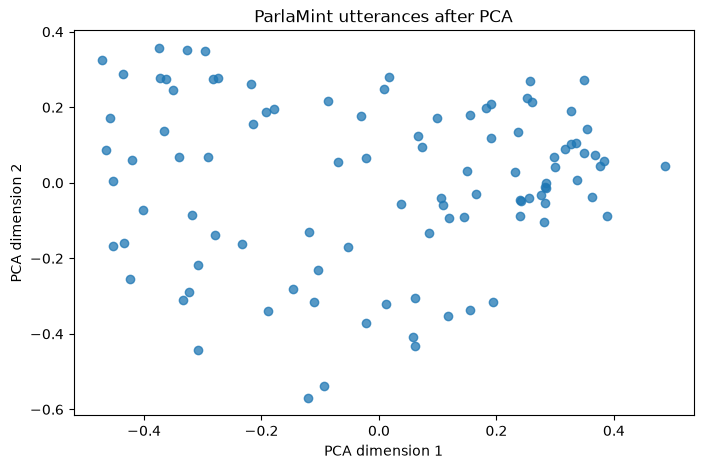

In [18]:
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import display
from sklearn.decomposition import PCA
from sklearn.metrics import pairwise_distances

# One point = one grouped parliamentary utterance
utterance_texts = df_parlamint_grouped["utterance_text"].tolist()
X_utterances = st_model_small.encode(utterance_texts, show_progress_bar=True)

# Apply PCA to the utterance embedding matrix
pca_model = PCA(n_components=2)
X_pca = pca_model.fit_transform(X_utterances)

df_utterances_pca = df_parlamint_grouped[["Parent_ID", "utterance_text"]].copy()
df_utterances_pca[["PCA_1", "PCA_2"]] = X_pca

print("Explained variance:", pca_model.explained_variance_ratio_)
print("Total explained variance:", pca_model.explained_variance_ratio_.sum())

plt.figure(figsize=(8, 5))
plt.scatter(X_pca[:, 0], X_pca[:, 1], alpha=0.75)
plt.xlabel("PCA dimension 1")
plt.ylabel("PCA dimension 2")
plt.title("ParlaMint utterances after PCA")
plt.show()

In [19]:
# PCA components are directions of variation, not topic labels.
# These examples help us inspect what kinds of language occur in different regions.

def show_examples(indices, title):
    print(f"\n{title}")
    print("=" * 100)
    for number, index in enumerate(indices, start=1):
        row = df_utterances_pca.iloc[index]
        print(f"Sample {number}")
        print(f"Parent_ID: {row['Parent_ID']}")
        print(f"PCA coordinates: ({row['PCA_1']:.4f}, {row['PCA_2']:.4f})")
        print("Full utterance:")
        print(row["utterance_text"])
        print("-" * 100)

# Find the closest and farthest pairs in the 2D PCA projection.
pca_distances = pairwise_distances(X_pca, metric="euclidean")
np.fill_diagonal(pca_distances, np.inf)

closest_pair = np.unravel_index(np.argmin(pca_distances), pca_distances.shape)

pca_distances_for_max = pca_distances.copy()
np.fill_diagonal(pca_distances_for_max, -np.inf)
farthest_pair = np.unravel_index(np.argmax(pca_distances_for_max), pca_distances.shape)

print("Distance between closest pair:", pca_distances[closest_pair])
show_examples(list(closest_pair), "Closest utterance pair in the PCA projection")

print("Distance between farthest pair:", pca_distances_for_max[farthest_pair])
show_examples(list(farthest_pair), "Farthest utterance pair in the PCA projection")

# Inspect utterances at the extremes of each principal-component axis.
for component in ["PCA_1", "PCA_2"]:
    low_indices = df_utterances_pca[component].nsmallest(3).index.tolist()
    high_indices = df_utterances_pca[component].nlargest(3).index.tolist()
    show_examples(low_indices, f"Lowest values on {component}")
    show_examples(high_indices, f"Highest values on {component}")

Distance between closest pair: 0.0015681853

Closest utterance pair in the PCA projection
Sample 1
Parent_ID: ParlaMint-IS_2022-01-17-20.u54
PCA coordinates: (0.2831, -0.0121)
Full utterance:
This is the subject for a considerably longer answer than the minute I have here. As for when we're in a place where we're supposed to have fewer restrictions and that people can go to a restaurant if they choose to sit there for longer than 9 in the evening, it's certainly a major blow for this part of a job, and he's had to take a lot of action. But with support, we too have responded greatly. Of course, as soon as we get it all together, we want to get back to normal. About the first question why. The senator is the calculated amount of money that you personally give, so that the question is answered here in the Sermon on the Mount.
----------------------------------------------------------------------------------------------------
Sample 2
Parent_ID: ParlaMint-IS_2022-01-17-20.u56
PCA coordina

## Dimensionality Reduction with UMAP

📌 **Example: ParlaMint Utterances**

Each of the 100 grouped parliamentary utterances is represented by a 384-dimensional Sentence Transformer vector:

```text
100 utterances × 384 dimensions
              ↓ UMAP
100 utterances × 2 dimensions
```

UMAP asks which utterances are nearest to one another. For example, utterances about climate policy may form a local neighborhood, while procedural utterances may form another.

---

### 🟢 UMAP

**Uniform Manifold Approximation and Projection**:

- Non-linear dimensionality-reduction technique
- Preserves local neighborhoods in the embedding space
- Default dimensionality-reduction method in BERTopic
- Commonly followed by **HDBSCAN** clustering

Conceptually:

$$
\text{similarity in the original embedding space}
\approx
\text{similarity in the reduced space}
$$

---

### 🟣 Why UMAP Can Be Preferable to PCA

- Captures **non-linear semantic structure** that PCA cannot represent
- Preserves **local neighborhoods** more directly
- Often makes compact semantic groups easier to inspect and cluster

💡 UMAP is not always better than PCA; PCA remains a useful, fast, and interpretable baseline.

## How UMAP Works — High-Level View

UMAP reduces the embedding space in two main stages:

```text
high-dimensional embeddings
          ↓
  local neighbor graph
          ↓
 low-dimensional coordinates
```

### 🟢 Main Steps

1. **Find local neighbors**
   For each document (utterance), find its `n_neighbors` nearest utterances using e.g. cosine distance.

2. **Build a weighted graph**
   Nearby documents are connected more strongly than distant documents. This represents the local structure of the text collection.

3. **Create a low-dimensional layout**
   UMAP places the documents in two or more dimensions.

4. **Optimize the layout**
   It pulls connected neighbors together and pushes unrelated points apart, trying to preserve the original neighborhood structure.

---

### 🟠 Important Parameters

- `n_neighbors`: how many nearest neighbors UMAP considers for each individual sample when building the neighborhood graph.
- `min_dist`: how tightly points may be packed in the low-dimensional representation.
- `n_components`: number of output dimensions

Batches: 100%|██████████| 4/4 [00:01<00:00,  2.14it/s]


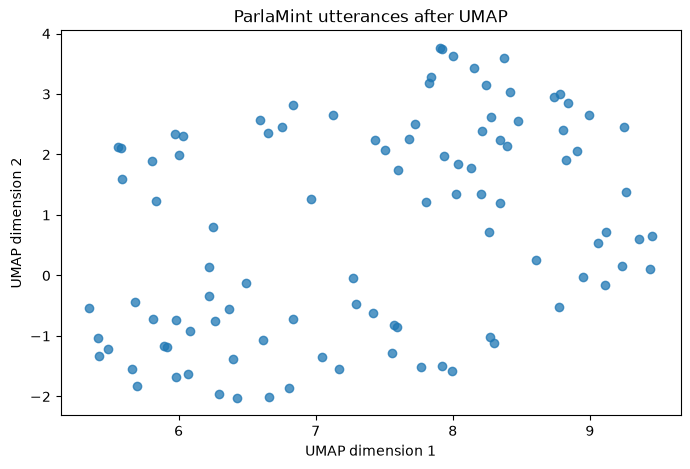

In [20]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import pairwise_distances
from umap import UMAP

# One point = one grouped parliamentary utterance
utterance_texts = df_parlamint_grouped["utterance_text"].tolist()
X_utterances = st_model_small.encode(utterance_texts, show_progress_bar=True)

# Reduce 384-dimensional sentence embeddings to two coordinates
umap_model = UMAP(
    n_neighbors=15,
    n_components=2,
    min_dist=0.1,
    metric="cosine",
    random_state=42,
)
X_umap = umap_model.fit_transform(X_utterances)

df_utterances_umap = df_parlamint_grouped[["Parent_ID", "utterance_text"]].copy()
df_utterances_umap[["UMAP_1", "UMAP_2"]] = X_umap

plt.figure(figsize=(8, 5))
plt.scatter(X_umap[:, 0], X_umap[:, 1], alpha=0.75)
plt.xlabel("UMAP dimension 1")
plt.ylabel("UMAP dimension 2")
plt.title("ParlaMint utterances after UMAP")
plt.show()

In [21]:
# UMAP is mainly useful for inspecting local neighborhoods.
# Its axes do not have the same variance-based interpretation as PCA.

def show_umap_examples(indices, title):
    print(f"\n{title}")
    print("=" * 100)
    for number, index in enumerate(indices, start=1):
        row = df_utterances_umap.iloc[index]
        print(f"Sample {number}")
        print(f"Parent_ID: {row['Parent_ID']}")
        print(f"UMAP coordinates: ({row['UMAP_1']:.4f}, {row['UMAP_2']:.4f})")
        print("Full utterance:")
        print(row["utterance_text"])
        print("-" * 100)

# Inspect closest and farthest pairs in the 2D UMAP layout.
# The closest pair is informative about a local neighborhood.
# The farthest pair should not be interpreted as a global semantic opposite.
umap_distances = pairwise_distances(X_umap, metric="euclidean")
np.fill_diagonal(umap_distances, np.inf)

closest_pair = np.unravel_index(np.argmin(umap_distances), umap_distances.shape)

umap_distances_for_max = umap_distances.copy()
np.fill_diagonal(umap_distances_for_max, -np.inf)
farthest_pair = np.unravel_index(np.argmax(umap_distances_for_max), umap_distances.shape)

print("Distance between closest pair in the UMAP layout:", umap_distances[closest_pair])
show_umap_examples(list(closest_pair), "Closest utterance pair in the UMAP layout")

print("Distance between farthest pair in the UMAP layout:", umap_distances_for_max[farthest_pair])
show_umap_examples(list(farthest_pair), "Farthest utterance pair in the UMAP layout")

# Inspect utterances at the extremes of each UMAP axis.
# Unlike PCA, these extremes do not represent principal components.
for dimension in ["UMAP_1", "UMAP_2"]:
    low_indices = df_utterances_umap[dimension].nsmallest(3).index.tolist()
    high_indices = df_utterances_umap[dimension].nlargest(3).index.tolist()
    show_umap_examples(low_indices, f"Lowest values on {dimension}")
    show_umap_examples(high_indices, f"Highest values on {dimension}")

Distance between closest pair in the UMAP layout: 0.016885376

Closest utterance pair in the UMAP layout
Sample 1
Parent_ID: ParlaMint-IS_2022-01-17-20.u52
UMAP coordinates: (7.9073, 3.7606)
Full utterance:
If I understood why. A senator right-if not, he will repeat it in a second answer-if you are already using a form of resources, you are not included in divorces, it is just the general mischievement that applies, but not even if you are using certain support. In terms of growth, that's what this takes, that postponement is, in fact, fruitless. In terms of the calculated price, there is something I would need to have an opportunity to ask about, the technical aspect, and would like an opportunity to do it and to come up and review the output in it.
----------------------------------------------------------------------------------------------------
Sample 2
Parent_ID: ParlaMint-IS_2022-01-17-20.u55
UMAP coordinates: (7.9183, 3.7478)
Full utterance:
That's exactly what I'd like to ask 

## Alternative Reductions & No Reduction

### 🟢 Alternatives Mentioned in BERTopic

| Method | Typical Use |
|---|---|
| **Truncated SVD** | Sparse matrices such as TF-IDF |
| **Incremental PCA** | Very large datasets |
| **t-SNE** | Mainly visualization |
| **PaCMAP** | Non-linear visualization and structure preservation |
| **TriMAP** | Preserving local and global relationships |
| **cuML UMAP** | GPU-accelerated UMAP |

---

### 🟠 No Dimensionality Reduction

A useful baseline is to cluster the original document embeddings directly:

```text
Document embeddings → HDBSCAN
```

This provides a reference for comparison:

- Does dimensionality reduction improve the clusters?
- Which documents change group?
- Do the resulting topics become more coherent?

💡 Dimensionality reduction is a modeling choice, not an automatic requirement.

## 🏋️ Experiments: Dimensionality Reduction

### 🟠 Work with the ParlaMint utterance embeddings

Use the [dimensionality-reduction notebook](../processing_dimensionality_reduction.ipynb) to:

- group the ParlaMint sentences into utterances;
- generate one Sentence Transformer embedding per utterance;
- reduce the embeddings to two dimensions with **PCA** and **UMAP**;
- visualize and compare the two layouts.

---

### 🟠 Compare PCA and UMAP

- Compare the explained variance reported by PCA.
- Inspect the global structure shown by PCA.
- Inspect the local neighborhoods shown by UMAP.
- Identify utterances that are close together or far apart in each reduced space.
- Read the full texts behind selected points and consider whether they share a topic, parliamentary style, or discourse function.

---

### 🟠 Experiment with the parameters

- Change PCA `n_components`.
- Change UMAP `n_neighbors`, `min_dist`, and `metric`.
- Compare dimensionality reduction with the original embeddings as a baseline.

---

### 🟠 Analyse also the other datasets
- **Same tasks as for the Parlamint dataset**

## Adding It All Together

### 🟢 Embeddings in BERTopic

- **Sparse Vectors (BoW, TF-IDF):**
  High-dimensional, simple counts, no semantics
- **Dense Word Embeddings (Word2Vec, GloVe):**
  Compact vectors capturing basic word meaning
- **Contextual Models (BERT):**
  Token embeddings adapt to context
- **Sentence Transformers (SBERT):**
  Sentence-level semantic embeddings for similarity & search
- **Chunking Strategies:**
  Break long texts into meaningful, model-friendly pieces

---

### 🟠 Why It Matters
- Transform raw text into **meaningful numerical representations**
- Enable **semantic search, clustering, Q&A, recommendations**
- Foundation for **modern NLP pipelines & AI assistants**

---

### 🔵 Key Takeaway
A well-designed embedding pipeline =
**Chunking + Contextual Models + Smart Similarity Metrics**
→ Powerful, scalable text understanding!

## Adding It All Together (cont'd)

### 🟢 Dimensionality Reduction in BERTopic

Sentence or document embeddings place texts in a high-dimensional semantic space. Dimensionality reduction transforms this space before clustering.

```text
document embeddings
        ↓
  UMAP / PCA
        ↓
   HDBSCAN
        ↓
  topic representation
```

---

### 🟠 Main Choices

- **UMAP:** preserves local semantic neighborhoods; BERTopic's default
- **PCA:** linear, fast, and useful as a comparison baseline
- **No reduction:** useful for testing whether reduction improves clustering

---

### 🔵 Key Point

* Dimensionality reduction does not create topic names.
* It changes the representation of documents so that clustering can identify meaningful groups.
* In BERTopic, the reduction method and its settings can influence the topics that are discovered.